# 04 — Evaluation & Business Impact
**Defect Vision System**

Goal: evaluate the trained model on the held-out test set and translate classification performance into a business cost report.

In [1]:
import sys
from pathlib import Path
import os
import json

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow import keras

sys.path.append(str(Path.cwd().parent))
os.chdir(Path.cwd().parent)
from src.utils.config import load_config
from src.models.evaluate_model import load_test_set

config = load_config()
model_cfg = config['model']
model = keras.models.load_model(model_cfg['saved_model_path'])
with open(model_cfg['class_names_path']) as f:
    class_names = json.load(f)

I0000 00:00:1782679650.393100     896 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782679650.432490     896 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782679651.681338     896 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Load the test set and run predictions

In [2]:
processed_dir = Path(config['data']['processed_dir'])
target_size = tuple(model_cfg['target_size'])

X_test, y_test, paths = load_test_set(processed_dir, class_names, target_size)
print(f'Test set: {X_test.shape[0]} images')

probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(probs, axis=1)

Test set: 360 images


## Classification report & confusion matrix

              precision    recall  f1-score   support

   defective       1.00      0.97      0.98       180
        good       0.97      1.00      0.98       180

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



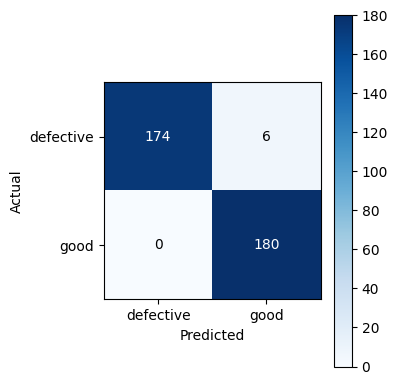

In [3]:
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names)
ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()

## Business cost analysis
A missed defect costs far more than a false alarm (a defective unit reaching a customer vs. a good unit getting double-checked), so we weight them differently and compare against a manual-inspection baseline (~85% human detection rate, a commonly cited figure in visual-QA literature).

In [4]:
biz = config['business']
defective_idx = class_names.index('defective')
good_idx = class_names.index('good')

missed_defects = np.sum((y_test == defective_idx) & (y_pred == good_idx))
false_alarms = np.sum((y_test == good_idx) & (y_pred == defective_idx))

manual_catch_rate = 0.85
n_test_defects = np.sum(y_test == defective_idx)
manual_missed = n_test_defects * (1 - manual_catch_rate)
manual_cost = manual_missed * biz['cost_per_missed_defect']
model_cost = missed_defects * biz['cost_per_missed_defect'] + false_alarms * biz['cost_per_false_alarm']

savings_vs_manual = manual_cost - model_cost
daily_savings = (savings_vs_manual / len(y_test)) * biz['units_inspected_per_day']

print(f'Missed defects: {missed_defects} / {n_test_defects}')
print(f'False alarms: {false_alarms}')
print(f'Estimated daily savings vs. manual inspection: ${daily_savings:,.2f}')

Missed defects: 6 / 180
False alarms: 0
Estimated daily savings vs. manual inspection: $2,479.17


## Conclusion
This system doesn't just classify images — it explains *why* (Grad-CAM) and translates that into an estimated *dollar impact* vs. the manual-inspection status quo. That combination — CNN + explainability + business framing — is the gap between a typical CV portfolio notebook and a production-style decision-support system, and it's the core idea behind this project.